In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score)
from sklearn.inspection import permutation_importance
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

df = pd.read_csv(r'C:\Users\SujitR\Desktop\rfai\mimo_beam_data.csv')
print(f"Dataset: {len(df):,} rows x {len(df.columns)} columns")
print(f"Cells: {df['cell_id'].nunique()} | Days: {df['date'].nunique()}")
print(f"\nScenario distribution:")
print(df.groupby('scenario')['cell_id'].nunique().to_string())

Dataset: 15,000 rows x 31 columns
Cells: 500 | Days: 30

Scenario distribution:
scenario
beam_failure         100
beam_misalignment    100
healthy              200
su_mimo_fallback     100


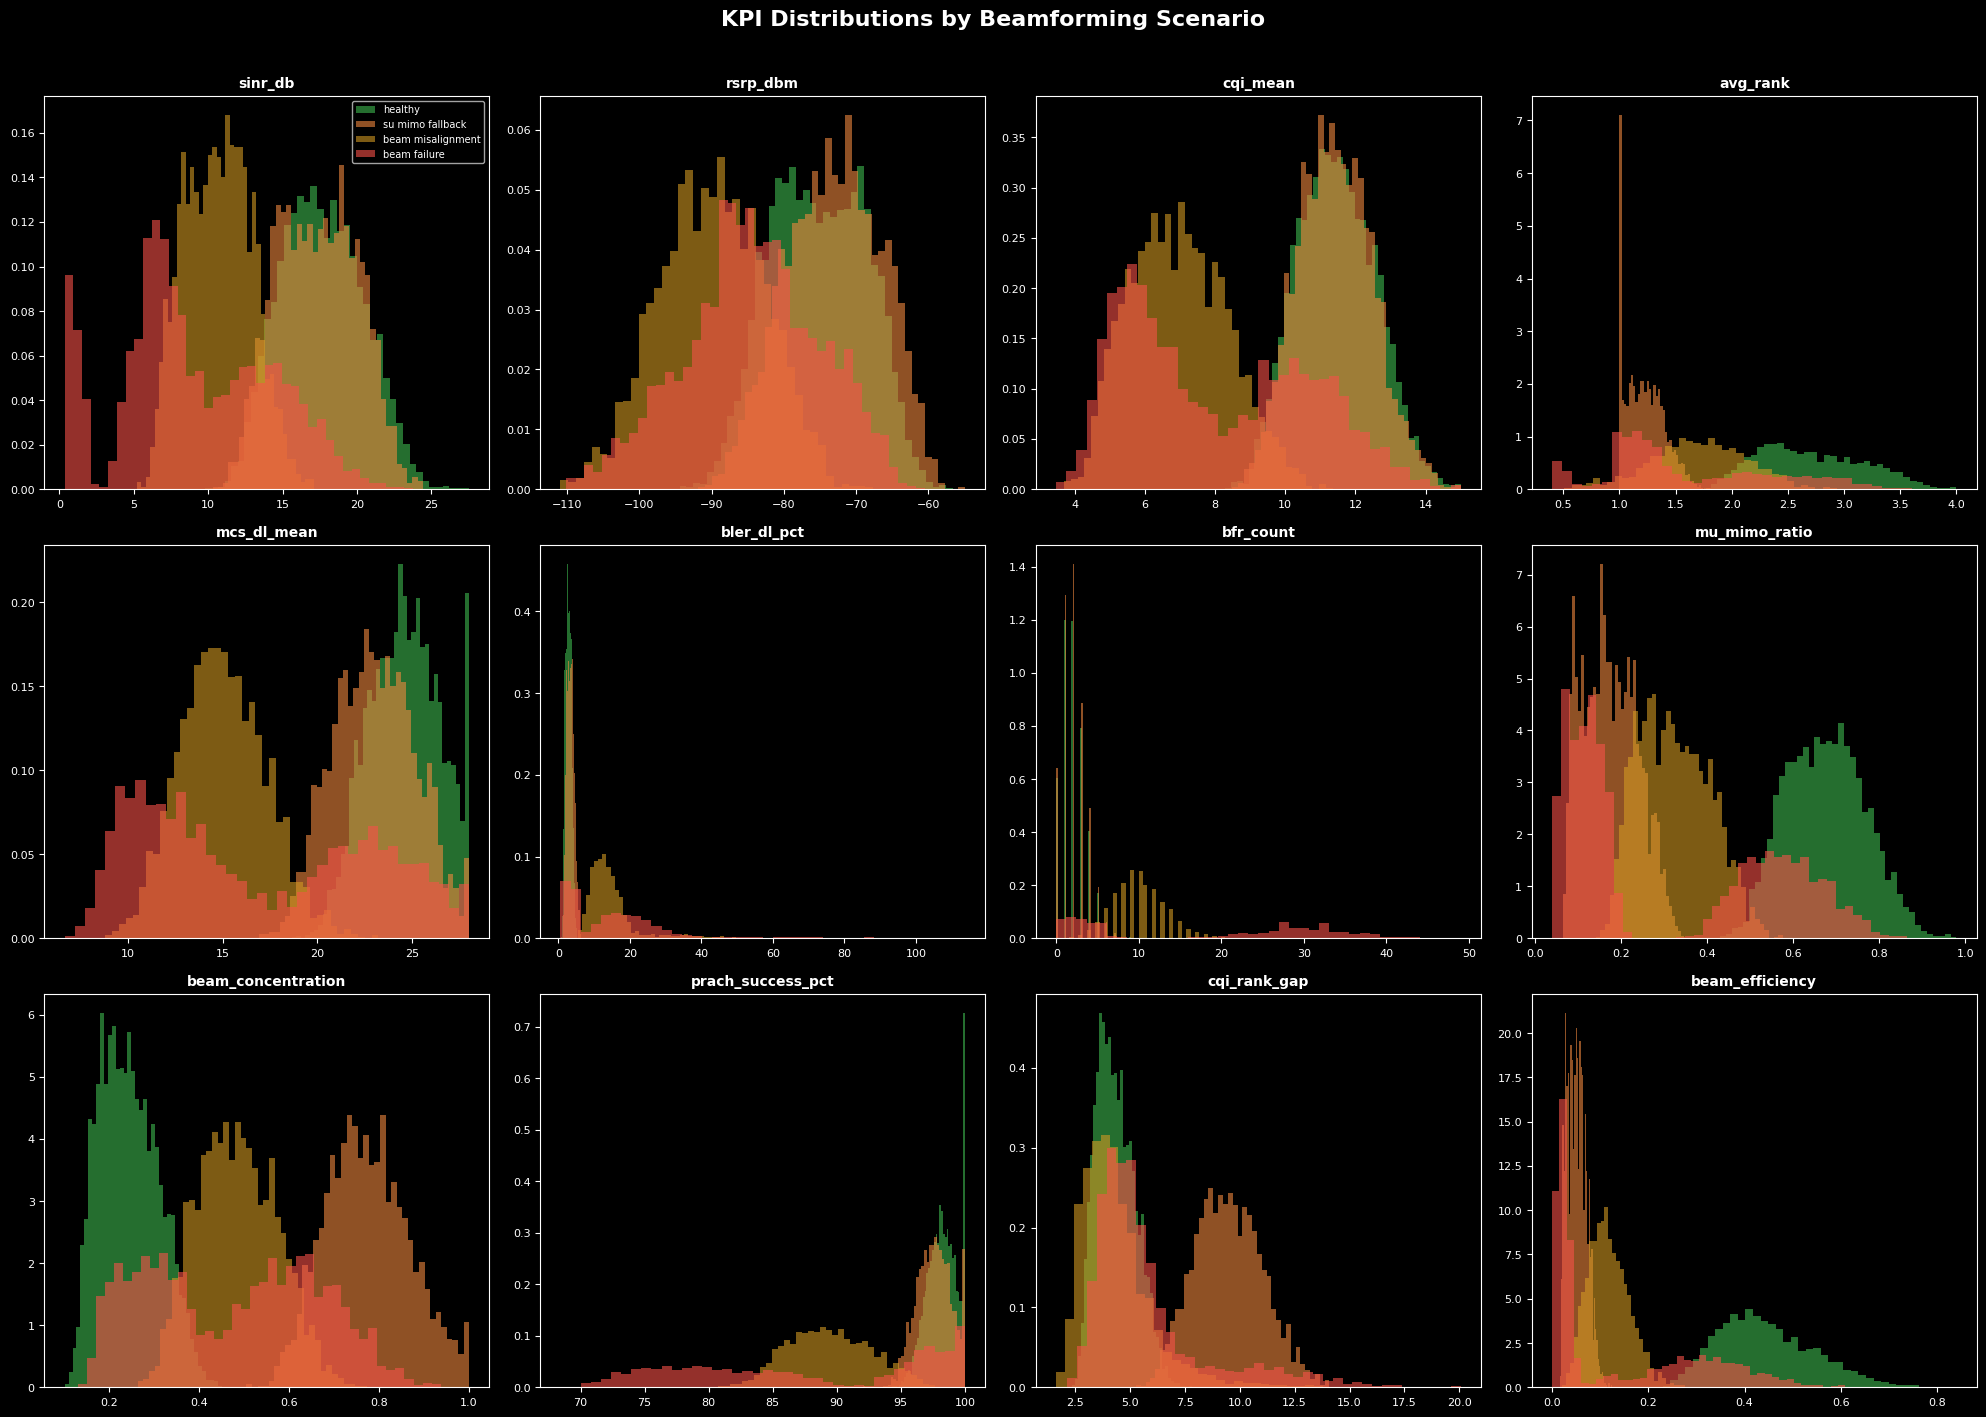

Saved: mimo_kpi_distributions.png


In [3]:
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

key_kpis = ['sinr_db', 'rsrp_dbm', 'cqi_mean', 'avg_rank',
            'mcs_dl_mean', 'bler_dl_pct', 'bfr_count',
            'mu_mimo_ratio', 'beam_concentration', 'prach_success_pct',
            'cqi_rank_gap', 'beam_efficiency']

colors = {
    'healthy':           '#3fb950',
    'su_mimo_fallback':  '#f0883e',
    'beam_misalignment': '#d29922',
    'beam_failure':      '#f85149',
}

for i, kpi in enumerate(key_kpis):
    ax = axes[i]
    for scenario, color in colors.items():
        data = df[df['scenario'] == scenario][kpi].dropna()
        ax.hist(data, bins=40, alpha=0.6, color=color,
                label=scenario.replace('_', ' '), density=True)
    ax.set_title(kpi, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(labelsize=8)
    if i == 0:
        ax.legend(fontsize=7)

plt.suptitle('KPI Distributions by Beamforming Scenario',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('mimo_kpi_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: mimo_kpi_distributions.png")

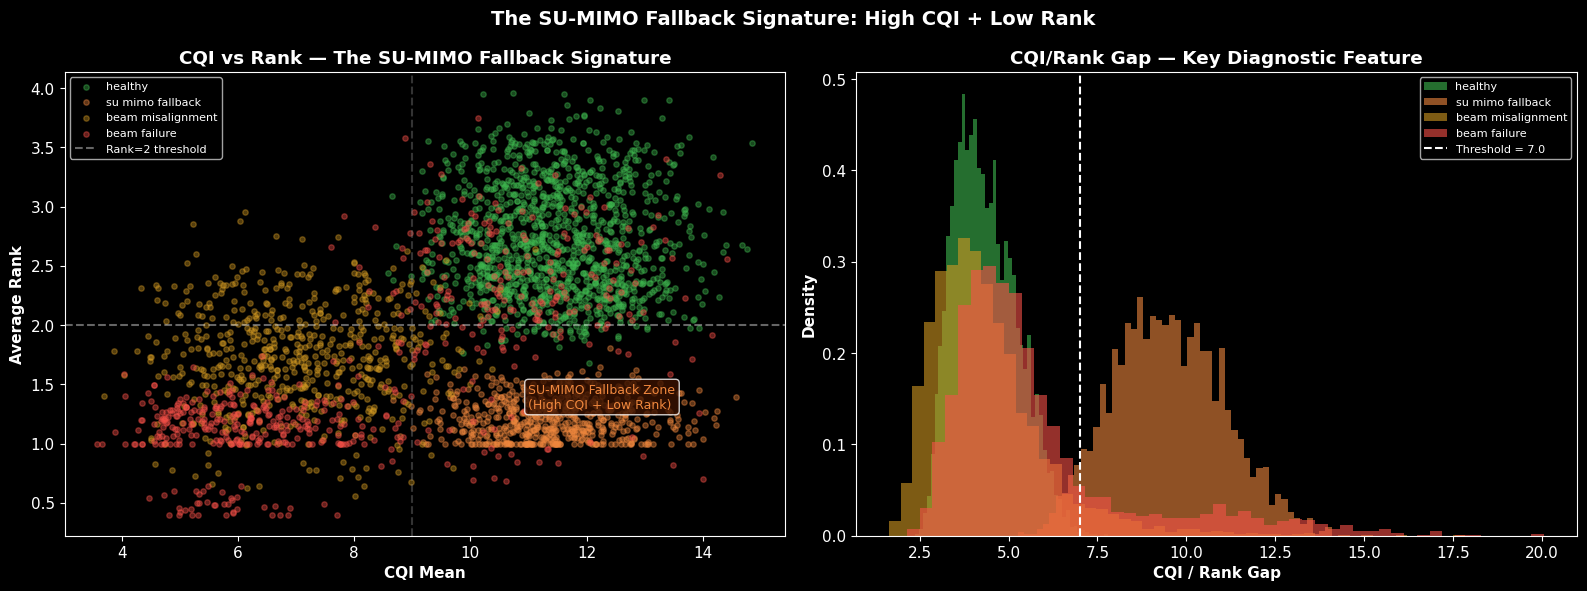

Saved: mimo_sumo_signature.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: CQI vs avg_rank colored by scenario
ax = axes[0]
sample = df.sample(3000, random_state=42)
for scenario, color in colors.items():
    sub = sample[sample['scenario'] == scenario]
    ax.scatter(sub['cqi_mean'], sub['avg_rank'],
               c=color, alpha=0.4, s=15,
               label=scenario.replace('_', ' '))

ax.axhline(y=2.0, color='white', linestyle='--', alpha=0.4,
           label='Rank=2 threshold')
ax.axvline(x=9.0, color='gray', linestyle='--', alpha=0.4)
ax.set_xlabel('CQI Mean', fontweight='bold')
ax.set_ylabel('Average Rank', fontweight='bold')
ax.set_title('CQI vs Rank — The SU-MIMO Fallback Signature',
             fontweight='bold')
ax.legend(fontsize=8)

# Annotate the problem zone
ax.annotate('SU-MIMO Fallback Zone\n(High CQI + Low Rank)',
            xy=(11, 1.3), fontsize=9, color='#f0883e',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#3a1200', alpha=0.8))

# Right: cqi_rank_gap distribution — the diagnostic feature
ax2 = axes[1]
for scenario, color in colors.items():
    data = df[df['scenario'] == scenario]['cqi_rank_gap']
    ax2.hist(data, bins=50, alpha=0.6, color=color,
             label=scenario.replace('_', ' '), density=True)

ax2.axvline(x=7.0, color='white', linestyle='--',
            label='Threshold = 7.0')
ax2.set_xlabel('CQI / Rank Gap', fontweight='bold')
ax2.set_ylabel('Density', fontweight='bold')
ax2.set_title('CQI/Rank Gap — Key Diagnostic Feature',
              fontweight='bold')
ax2.legend(fontsize=8)

plt.suptitle('The SU-MIMO Fallback Signature: High CQI + Low Rank',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('mimo_sumo_signature.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: mimo_sumo_signature.png")

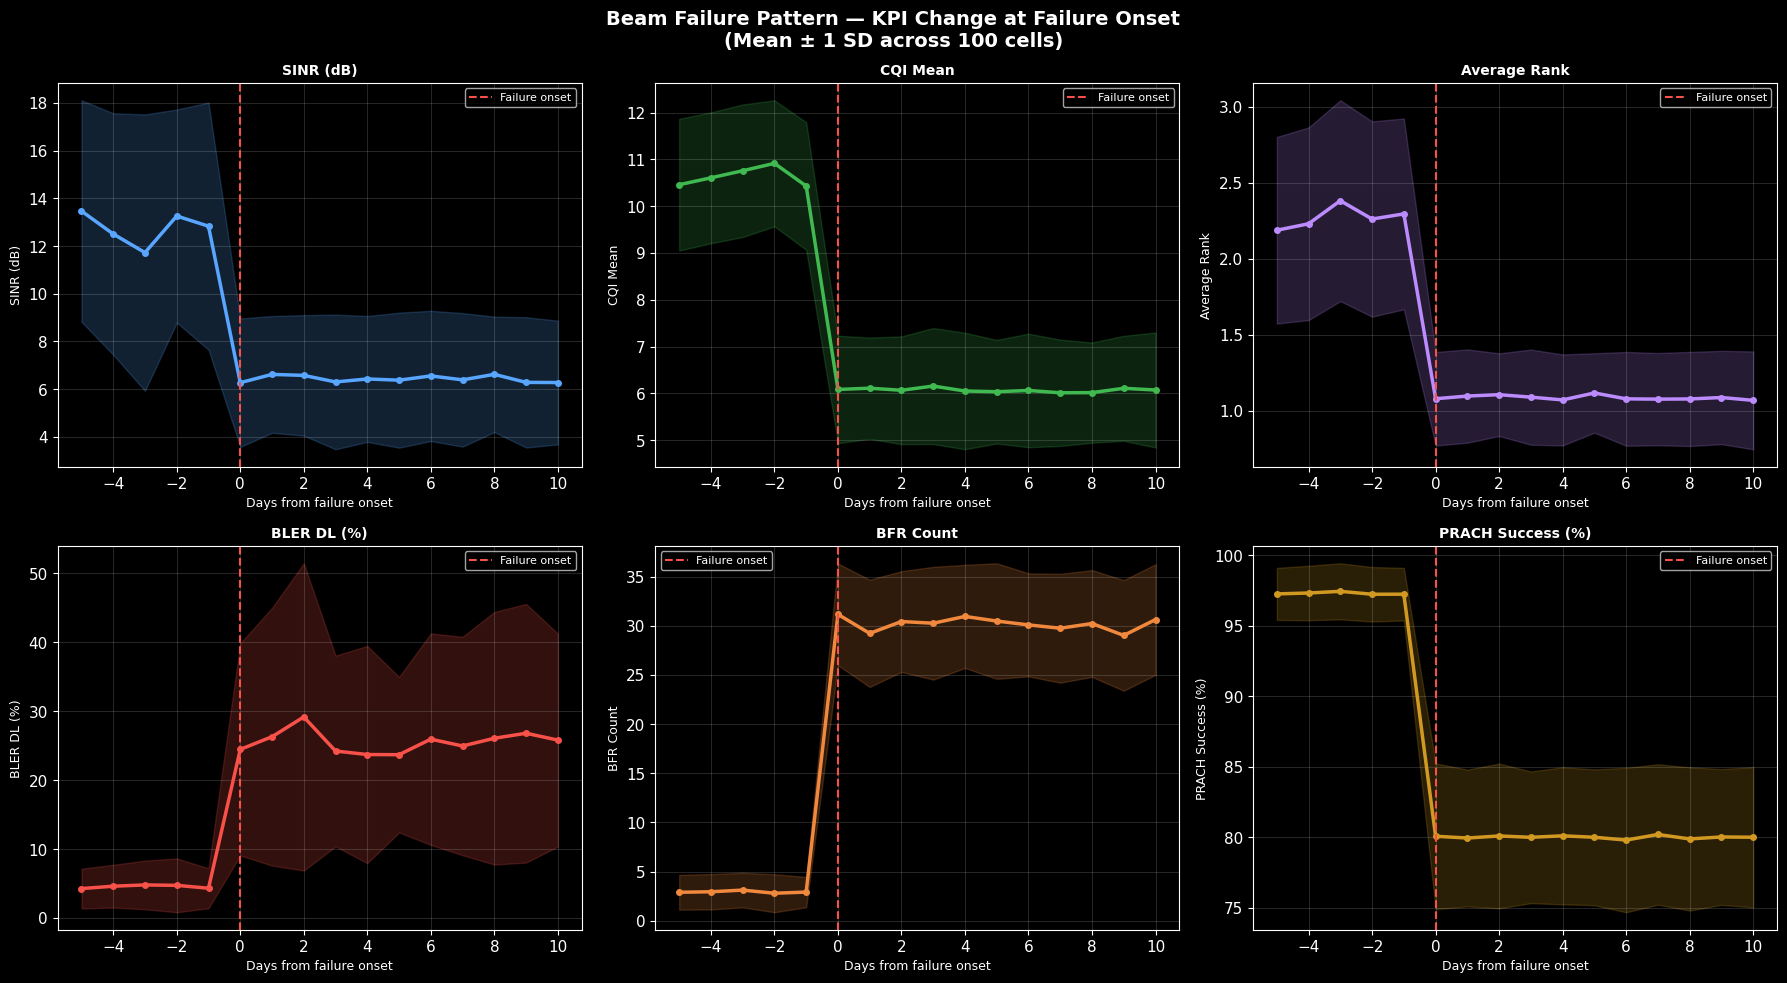

Saved: mimo_beam_failure_trend.png


In [5]:
# Show how KPIs change at failure onset for beam_failure cells
failure_cells = df[df['scenario'] == 'beam_failure'].copy()
failure_cells['day_num'] = failure_cells.groupby('cell_id')['date'].transform(
    lambda x: range(len(x))
)
failure_cells['days_from_failure'] = (
    failure_cells['day_num'] - failure_cells['failure_day']
)

# Align all cells by days from failure
aligned = failure_cells[
    failure_cells['days_from_failure'].between(-5, 10)
].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

kpis_to_plot = ['sinr_db', 'cqi_mean', 'avg_rank',
                'bler_dl_pct', 'bfr_count', 'prach_success_pct']
labels = ['SINR (dB)', 'CQI Mean', 'Average Rank',
          'BLER DL (%)', 'BFR Count', 'PRACH Success (%)']
kpi_colors = ['#58a6ff', '#3fb950', '#bc8cff',
              '#f85149', '#f0883e', '#d29922']

for i, (kpi, label, color) in enumerate(zip(kpis_to_plot, labels, kpi_colors)):
    ax = axes[i]
    grouped = aligned.groupby('days_from_failure')[kpi].agg(['mean', 'std'])
    x = grouped.index
    y = grouped['mean']
    e = grouped['std']

    ax.fill_between(x, y - e, y + e, color=color, alpha=0.2)
    ax.plot(x, y, color=color, linewidth=2.5, marker='o', markersize=4)
    ax.axvline(x=0, color='#f85149', linestyle='--',
               linewidth=1.5, label='Failure onset')
    ax.set_xlabel('Days from failure onset', fontsize=9)
    ax.set_ylabel(label, fontsize=9)
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.15)

plt.suptitle('Beam Failure Pattern — KPI Change at Failure Onset\n(Mean ± 1 SD across 100 cells)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('mimo_beam_failure_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: mimo_beam_failure_trend.png")

In [6]:
# Features for classification
FEATURE_COLS = [
    'sinr_db', 'rsrp_dbm', 'rsrq_db', 'cqi_mean',
    'avg_rank', 'mcs_dl_mean', 'bler_dl_pct', 'ul_bler_pct',
    'harq_retx_ratio', 'prb_util_dl_pct', 'ul_prb_util_pct',
    'active_users', 'traffic_volume_gb', 'mu_mimo_ratio',
    'rank_1_ratio', 'bfr_count', 'beam_switch_count',
    'beam_concentration', 'rrc_setup_success_pct',
    'drb_setup_success_pct', 'prach_success_pct',
    'pucch_util_pct', 'ul_rssi_dbm',
    'cqi_rank_gap', 'beam_efficiency', 'sinr_cqi_delta',
    'load_index'
]

# Use latest period per cell to avoid data leakage
latest = df.sort_values('date').groupby('cell_id').last().reset_index()

X = latest[FEATURE_COLS]
y = latest['scenario']

# Encode labels
le = LabelEncoder()
y_enc = le.fit_transform(y)

# Train/test split — stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=le.classes_, digits=3))

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y_enc, cv=cv, scoring='accuracy')
print(f"\n5-Fold Cross-Validation:")
print(f"  Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"  Scores:   {[round(s,3) for s in cv_scores]}")

Classification Report:
                   precision    recall  f1-score   support

     beam_failure      1.000     1.000     1.000        20
beam_misalignment      1.000     1.000     1.000        20
          healthy      1.000     1.000     1.000        40
 su_mimo_fallback      1.000     1.000     1.000        20

         accuracy                          1.000       100
        macro avg      1.000     1.000     1.000       100
     weighted avg      1.000     1.000     1.000       100


5-Fold Cross-Validation:
  Accuracy: 1.000 ± 0.000
  Scores:   [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]


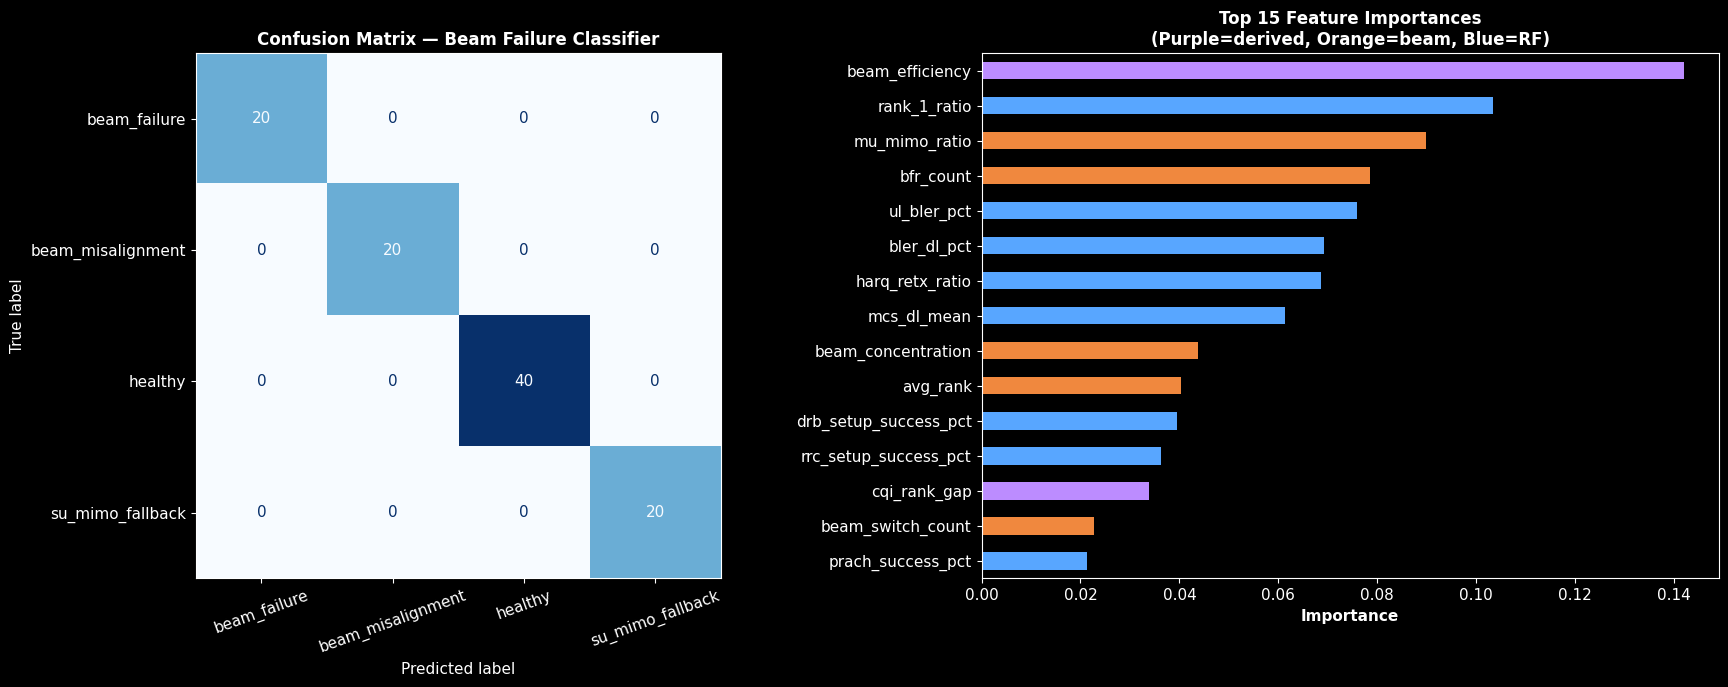

Saved: mimo_classifier_results.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=le.classes_)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Beam Failure Classifier',
                  fontweight='bold', fontsize=12)
axes[0].tick_params(axis='x', rotation=20)

# Feature importance
importances = pd.Series(rf.feature_importances_,
                        index=FEATURE_COLS).sort_values(ascending=True)
top15 = importances.tail(15)

bar_colors = []
for feat in top15.index:
    if feat in ['cqi_rank_gap', 'beam_efficiency', 'sinr_cqi_delta']:
        bar_colors.append('#bc8cff')   # derived features — purple
    elif feat in ['avg_rank', 'mu_mimo_ratio', 'beam_concentration',
                  'bfr_count', 'beam_switch_count']:
        bar_colors.append('#f0883e')   # beam features — orange
    else:
        bar_colors.append('#58a6ff')   # RF features — blue

top15.plot(kind='barh', ax=axes[1], color=bar_colors)
axes[1].set_title('Top 15 Feature Importances\n'
                  '(Purple=derived, Orange=beam, Blue=RF)',
                  fontweight='bold', fontsize=12)
axes[1].set_xlabel('Importance', fontweight='bold')

plt.tight_layout()
plt.savefig('mimo_classifier_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: mimo_classifier_results.png")

In [8]:
def score_cell_beam_health(cell_data):
    """
    Given a cell's latest KPI readings, returns:
    - beam_scenario: predicted failure type
    - confidence: prediction probability
    - flags: specific issues detected
    - recommendations: actionable fixes
    """
    # Predict scenario
    X_cell = pd.DataFrame([cell_data])[FEATURE_COLS]
    proba  = rf.predict_proba(X_cell)[0]
    pred   = le.inverse_transform([np.argmax(proba)])[0]
    conf   = round(float(np.max(proba)), 3)

    # Rule-based flags on top of ML prediction
    flags = []
    recs  = []

    cqr  = cell_data.get('cqi_rank_gap', 0)
    rank = cell_data.get('avg_rank', 2)
    bfc  = cell_data.get('bfr_count', 0)
    bsc  = cell_data.get('beam_switch_count', 0)
    bcon = cell_data.get('beam_concentration', 0)
    mu   = cell_data.get('mu_mimo_ratio', 0.5)
    prs  = cell_data.get('prach_success_pct', 98)
    harq = cell_data.get('harq_retx_ratio', 0.1)
    bler = cell_data.get('bler_dl_pct', 3)
    mcs  = cell_data.get('mcs_dl_mean', 20)
    cqi  = cell_data.get('cqi_mean', 10)
    users= cell_data.get('active_users', 5)

    if cqr > 7.0 and rank < 1.8:
        flags.append(f"SU-MIMO fallback (CQI/rank gap={cqr:.1f})")
        recs.append("Check UE spatial distribution via drive test")
        recs.append("Review SSB beam configuration and sector split")
    if bcon > 0.65:
        flags.append(f"High beam concentration ({bcon:.2f}) — UEs clustered")
        recs.append("Consider cell azimuth adjustment or sector split")
    if bsc > 15:
        flags.append(f"High beam switching ({bsc:.0f}/day) — unstable beams")
        recs.append("Audit SSB beam sweep configuration")
        recs.append("Check for antenna mechanical issues")
    if bfc > 20:
        flags.append(f"High BFR count ({bfc:.0f}) — beam failures")
        recs.append("Immediate field investigation — possible hardware fault")
    if prs < 93:
        flags.append(f"Low PRACH success ({prs:.1f}%) — access beam issue")
        recs.append("Review SSB beam sweep pattern for initial access")
    if harq > 0.20:
        flags.append(f"High HARQ retransmissions ({harq:.2f}) — post-beam quality poor")
    if mu < 0.20 and users > 8:
        flags.append(f"Low MU-MIMO ratio ({mu:.2f}) with {users} users active")
        recs.append("Verify MU-MIMO pairing is enabled")

    return {
        'scenario':        pred,
        'confidence':      conf,
        'all_proba':       dict(zip(le.classes_, [round(float(p),3) for p in proba])),
        'flags':           flags,
        'recommendations': list(dict.fromkeys(recs)),  # deduplicate
        'flag_count':      len(flags),
    }

# Demo: score first cell of each scenario
print("=" * 70)
print("BEAM HEALTH ASSESSMENT — SAMPLE CELLS")
print("=" * 70)
for sc in ['healthy','su_mimo_fallback','beam_misalignment','beam_failure']:
    sample_cell = df[df['scenario'] == sc].iloc[-1].to_dict()
    result = score_cell_beam_health(sample_cell)
    print(f"\nCell: {sample_cell['cell_id']}  |  True scenario: {sc}")
    print(f"  Predicted: {result['scenario']}  (confidence: {result['confidence']:.1%})")
    print(f"  All proba: {result['all_proba']}")
    if result['flags']:
        for flag in result['flags']:
            print(f"  ⚠ {flag}")
        for rec in result['recommendations']:
            print(f"  → {rec}")
    else:
        print("  ✓ No beam issues detected")

BEAM HEALTH ASSESSMENT — SAMPLE CELLS

Cell: Cell_0499  |  True scenario: healthy
  Predicted: healthy  (confidence: 100.0%)
  All proba: {'beam_failure': 0.0, 'beam_misalignment': 0.0, 'healthy': 1.0, 'su_mimo_fallback': 0.0}
  ✓ No beam issues detected

Cell: Cell_0496  |  True scenario: su_mimo_fallback
  Predicted: su_mimo_fallback  (confidence: 99.3%)
  All proba: {'beam_failure': 0.0, 'beam_misalignment': 0.007, 'healthy': 0.0, 'su_mimo_fallback': 0.993}
  ⚠ SU-MIMO fallback (CQI/rank gap=9.5)
  ⚠ High beam concentration (0.71) — UEs clustered
  ⚠ Low MU-MIMO ratio (0.15) with 18.0 users active
  → Check UE spatial distribution via drive test
  → Review SSB beam configuration and sector split
  → Consider cell azimuth adjustment or sector split
  → Verify MU-MIMO pairing is enabled

Cell: Cell_0497  |  True scenario: beam_misalignment
  Predicted: beam_misalignment  (confidence: 99.5%)
  All proba: {'beam_failure': 0.005, 'beam_misalignment': 0.995, 'healthy': 0.0, 'su_mimo_fallb

In [10]:
# ── Cell 9: Isolation Forest + RF Combined System ──────────

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# ── Step 1: Train Isolation Forest ────────────────────────
# Train ONLY on healthy cells
# This way it learns what "normal" looks like
# and flags anything deviating from that

healthy_cells = latest[latest['scenario'] == 'healthy']
X_healthy     = healthy_cells[FEATURE_COLS]

scaler = StandardScaler()
X_healthy_scaled = scaler.fit_transform(X_healthy)

# contamination: expected fraction of anomalies
# in production data. We expect ~60% of cells
# to be non-healthy based on our scenario design
iso = IsolationForest(
    n_estimators=200,
    contamination=0.50,
    random_state=42,
    n_jobs=-1
)
iso.fit(X_healthy_scaled)

print("Isolation Forest trained on healthy cells only")
print(f"Training samples: {len(X_healthy)}")

Isolation Forest trained on healthy cells only
Training samples: 200


In [11]:
# ── Cell 10: Combined Detection Pipeline ───────────────────

CONFIDENCE_THRESHOLD = 0.70  # RF must be >70% confident
                               # otherwise → unknown_anomaly

def detect_beam_issue(cell_features_dict, cell_id="unknown"):
    """
    Full detection pipeline:
    1. Isolation Forest — is this cell anomalous?
    2. Random Forest    — which failure mode?
    3. Confidence check — known or unknown anomaly?
    
    Returns full diagnosis dictionary.
    """
    # Build feature array
    X_cell        = pd.DataFrame([cell_features_dict])[FEATURE_COLS]
    X_cell_scaled = scaler.transform(X_cell)

    # ── Stage 1: Isolation Forest ──────────────────────────
    iso_score     = float(iso.decision_function(X_cell_scaled)[0])
    iso_prediction= iso.predict(X_cell_scaled)[0]
    is_anomalous  = iso_prediction == -1

    # iso_score interpretation:
    # More negative = more anomalous
    # Around 0 = on the boundary
    # Positive = clearly normal

    if not is_anomalous:
        # Cell looks like healthy baseline
        # No need to run Random Forest
        return {
            'cell_id':          cell_id,
            'final_label':      'healthy',
            'detection_stage':  'isolation_forest',
            'iso_score':        round(iso_score, 4),
            'is_anomalous':     False,
            'rf_scenario':      None,
            'rf_confidence':    None,
            'flags':            [],
            'recommendations':  ['No beam issues detected'],
            'priority':         'none',
        }

    # ── Stage 2: Random Forest classification ──────────────
    # Cell IS anomalous — now classify which type
    proba      = rf.predict_proba(X_cell)[0]
    pred_idx   = np.argmax(proba)
    pred_label = le.inverse_transform([pred_idx])[0]
    confidence = float(np.max(proba))

    # ── Stage 3: Confidence check ──────────────────────────
    if confidence < CONFIDENCE_THRESHOLD:
        # Anomalous but doesn't clearly match any known scenario
        # → Unknown anomaly — new failure mode?
        return {
            'cell_id':          cell_id,
            'final_label':      'unknown_anomaly',
            'detection_stage':  'isolation_forest + rf_uncertain',
            'iso_score':        round(iso_score, 4),
            'is_anomalous':     True,
            'rf_scenario':      pred_label,
            'rf_confidence':    round(confidence, 3),
            'all_proba':        dict(zip(le.classes_,
                                [round(float(p),3) for p in proba])),
            'flags':            ['Unknown anomaly pattern — does not match any trained scenario'],
            'recommendations':  [
                'Manual investigation required',
                'Compare against known failure mode signatures',
                'This may be a new failure mode — document findings',
                f'Closest match: {pred_label} ({confidence:.0%}) — verify'
            ],
            'priority':         'high',
        }

    # ── Known scenario — run rule-based flags ──────────────
    result = score_cell_beam_health(cell_features_dict)

    return {
        'cell_id':          cell_id,
        'final_label':      pred_label,
        'detection_stage':  'isolation_forest + random_forest',
        'iso_score':        round(iso_score, 4),
        'is_anomalous':     True,
        'rf_scenario':      pred_label,
        'rf_confidence':    round(confidence, 3),
        'all_proba':        result['all_proba'],
        'flags':            result['flags'],
        'recommendations':  result['recommendations'],
        'priority':         _get_priority(pred_label, confidence),
    }

def _get_priority(scenario, confidence):
    priority_map = {
        'beam_failure':      'critical',
        'beam_misalignment': 'high',
        'su_mimo_fallback':  'medium',
        'healthy':           'none',
    }
    base = priority_map.get(scenario, 'high')
    # Downgrade priority if confidence is moderate
    if confidence < 0.85 and base == 'critical':
        return 'high'
    return base

print("Combined detection pipeline ready")
print(f"Confidence threshold: {CONFIDENCE_THRESHOLD:.0%}")

Combined detection pipeline ready
Confidence threshold: 70%


In [12]:
# ── Cell 11: Score all cells ────────────────────────────────

all_results = []
for _, row in latest.iterrows():
    result = detect_beam_issue(row.to_dict(), cell_id=row['cell_id'])
    result['true_scenario'] = row['scenario']
    all_results.append(result)

results_df = pd.DataFrame(all_results)

# ── Summary ────────────────────────────────────────────────
print("=" * 65)
print("COMBINED ISOLATION FOREST + RANDOM FOREST RESULTS")
print("=" * 65)

print(f"\nTotal cells analyzed: {len(results_df)}")
print(f"\nDetection breakdown:")
print(f"  Caught by Isolation Forest (healthy):  "
      f"{(results_df['final_label']=='healthy').sum()}")
print(f"  Known scenario (RF high confidence):   "
      f"{results_df['final_label'].isin(['su_mimo_fallback','beam_misalignment','beam_failure']).sum()}")
print(f"  Unknown anomaly (RF uncertain):        "
      f"{(results_df['final_label']=='unknown_anomaly').sum()}")

print(f"\nFinal label distribution:")
print(results_df['final_label'].value_counts().to_string())

print(f"\nPriority breakdown:")
print(results_df['priority'].value_counts().to_string())

# ── How well did it match true scenarios? ─────────────────
known = results_df[results_df['final_label'] != 'unknown_anomaly']
correct = (known['final_label'] == known['true_scenario']).mean()
print(f"\nAccuracy on known scenarios: {correct:.1%}")

# ── Show unknown anomalies if any ─────────────────────────
unknowns = results_df[results_df['final_label'] == 'unknown_anomaly']
if len(unknowns) > 0:
    print(f"\nUnknown anomalies detected ({len(unknowns)} cells):")
    print(unknowns[['cell_id', 'true_scenario',
                     'rf_scenario', 'rf_confidence',
                     'iso_score']].to_string())
else:
    print("\nNo unknown anomalies — all cells clearly classified")
    print("(Expected with clean synthetic data)")
    print("Unknown anomalies will appear with real network data")
    print("when failure modes not in training data are encountered")

COMBINED ISOLATION FOREST + RANDOM FOREST RESULTS

Total cells analyzed: 500

Detection breakdown:
  Caught by Isolation Forest (healthy):  200
  Known scenario (RF high confidence):   300
  Unknown anomaly (RF uncertain):        0

Final label distribution:
final_label
healthy              200
beam_misalignment    100
beam_failure         100
su_mimo_fallback     100

Priority breakdown:
priority
none        200
high        100
critical    100
medium      100

Accuracy on known scenarios: 100.0%

No unknown anomalies — all cells clearly classified
(Expected with clean synthetic data)
Unknown anomalies will appear with real network data
when failure modes not in training data are encountered


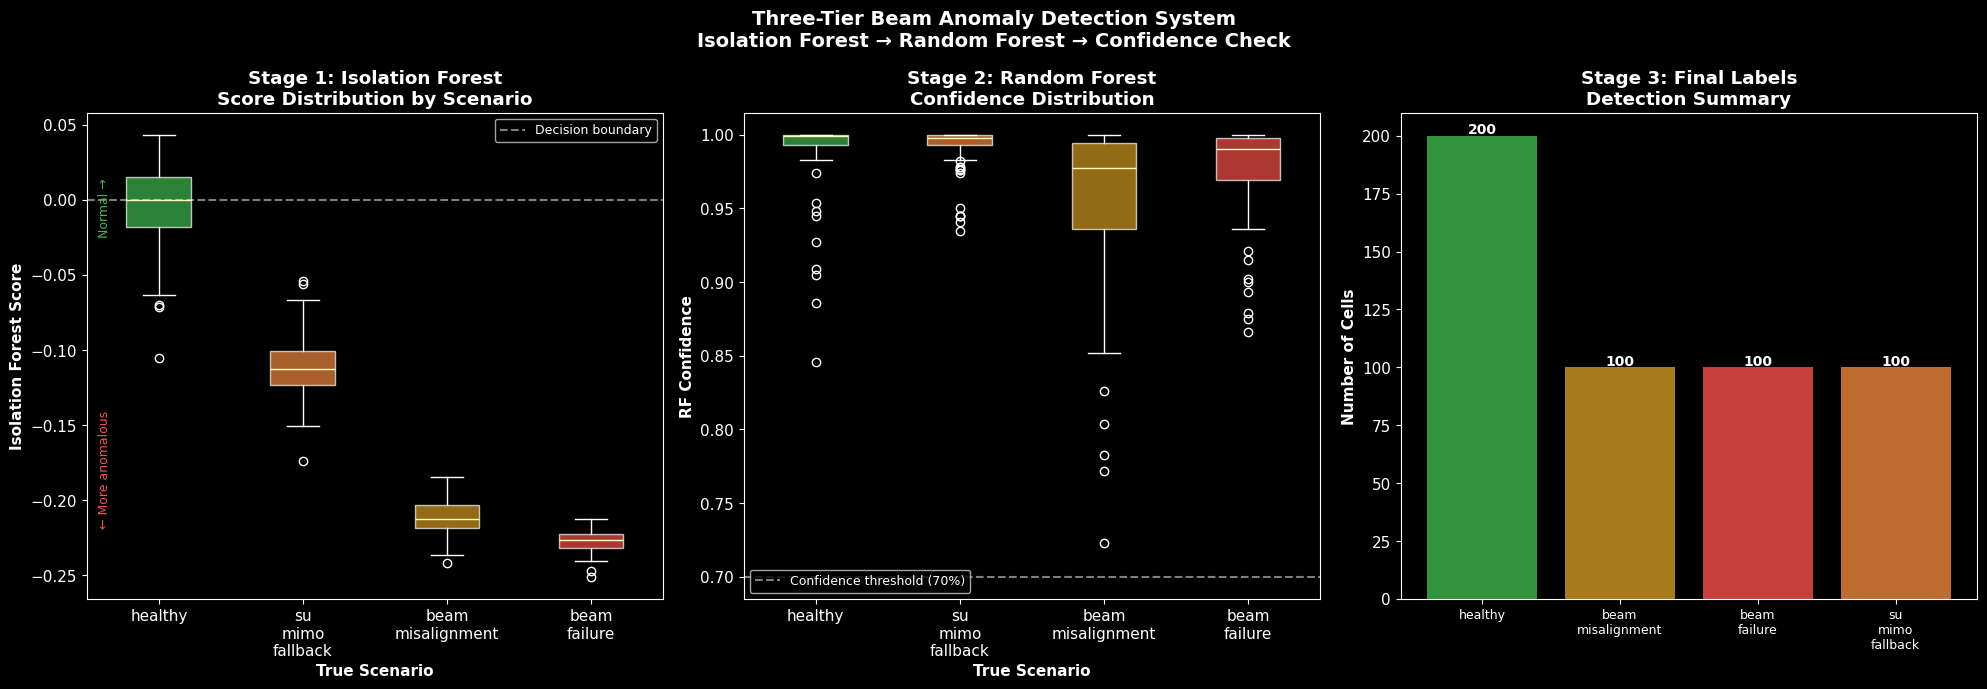

Saved: mimo_combined_detection.png


In [13]:
# ── Cell 12: Visualize detection tiers ─────────────────────

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# ── Left: Isolation Forest scores by true scenario ─────────
ax = axes[0]
scenario_order = ['healthy', 'su_mimo_fallback',
                  'beam_misalignment', 'beam_failure']
iso_scores = [
    results_df[results_df['true_scenario']==sc]['iso_score'].values
    for sc in scenario_order
]
bp = ax.boxplot(iso_scores, labels=[s.replace('_','\n')
                for s in scenario_order], patch_artist=True)

box_colors = ['#3fb950','#f0883e','#d29922','#f85149']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.axhline(y=0, color='white', linestyle='--',
           alpha=0.5, label='Decision boundary')
ax.set_ylabel('Isolation Forest Score', fontweight='bold')
ax.set_title('Stage 1: Isolation Forest\n'
             'Score Distribution by Scenario',
             fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlabel('True Scenario', fontweight='bold')

# More negative = more anomalous
ax.annotate('← More anomalous', xy=(0.02, 0.15),
            xycoords='axes fraction', fontsize=9,
            color='#f85149', rotation=90)
ax.annotate('Normal →', xy=(0.02, 0.75),
            xycoords='axes fraction', fontsize=9,
            color='#3fb950', rotation=90)

# ── Middle: RF confidence by scenario ──────────────────────
ax2 = axes[1]
conf_data = [
    results_df[results_df['true_scenario']==sc]['rf_confidence'].dropna().values
    for sc in scenario_order
]
bp2 = ax2.boxplot(conf_data, labels=[s.replace('_','\n')
                  for s in scenario_order], patch_artist=True)
for patch, color in zip(bp2['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.axhline(y=CONFIDENCE_THRESHOLD, color='white',
            linestyle='--', alpha=0.5,
            label=f'Confidence threshold ({CONFIDENCE_THRESHOLD:.0%})')
ax2.set_ylabel('RF Confidence', fontweight='bold')
ax2.set_title('Stage 2: Random Forest\n'
              'Confidence Distribution',
              fontweight='bold')
ax2.legend(fontsize=9)
ax2.set_xlabel('True Scenario', fontweight='bold')

# ── Right: Final detection summary ─────────────────────────
ax3 = axes[2]
label_counts = results_df['final_label'].value_counts()
label_colors = {
    'healthy':           '#3fb950',
    'su_mimo_fallback':  '#f0883e',
    'beam_misalignment': '#d29922',
    'beam_failure':      '#f85149',
    'unknown_anomaly':   '#bc8cff',
}
colors_ordered = [label_colors.get(l, '#666666')
                  for l in label_counts.index]
bars = ax3.bar(range(len(label_counts)),
               label_counts.values,
               color=colors_ordered, alpha=0.8)
ax3.set_xticks(range(len(label_counts)))
ax3.set_xticklabels([l.replace('_','\n')
                     for l in label_counts.index],
                    fontsize=9)
ax3.set_ylabel('Number of Cells', fontweight='bold')
ax3.set_title('Stage 3: Final Labels\n'
              'Detection Summary',
              fontweight='bold')

for bar, count in zip(bars, label_counts.values):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             str(count), ha='center',
             fontweight='bold', fontsize=10)

plt.suptitle('Three-Tier Beam Anomaly Detection System\n'
             'Isolation Forest → Random Forest → Confidence Check',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('mimo_combined_detection.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: mimo_combined_detection.png")

In [14]:
# ── Cell 13: Demonstrate unknown anomaly detection ─────────
# In real data this happens naturally when a new failure mode
# appears that the model wasn't trained on.
# Here we simulate it by creating a cell with a mixed/unusual pattern.

print("Simulating an unknown anomaly...")
print("(A cell that is anomalous but doesn't clearly")
print(" match any of the 4 trained scenarios)\n")

# Create a cell with unusual mixed pattern:
# High BFR (like beam_failure) BUT good SINR/CQI (like healthy)
# AND low rank (like su_mimo_fallback)
# AND low PRACH (like beam_misalignment)
# → No single trained scenario matches cleanly

unknown_cell = {kpi: latest[latest['scenario']=='healthy'][kpi].mean()
                for kpi in FEATURE_COLS}

# Inject the unusual pattern
unknown_cell.update({
    'sinr_db':            17.5,   # good — like healthy
    'cqi_mean':           11.2,   # good — like healthy
    'avg_rank':           1.3,    # low  — like su_mimo_fallback
    'bfr_count':          28.0,   # high — like beam_failure
    'prach_success_pct':  88.0,   # low  — like beam_misalignment
    'mu_mimo_ratio':      0.42,   # moderate — doesn't fit any
    'beam_concentration': 0.45,   # moderate
    'beam_switch_count':  22.0,   # high — like beam_misalignment
    'harq_retx_ratio':    0.08,   # low  — like healthy
    'bler_dl_pct':        3.5,    # low  — like healthy
})

# Recompute derived features
unknown_cell['cqi_rank_gap'] = (
    unknown_cell['cqi_mean'] /
    max(unknown_cell['avg_rank'], 0.5)
)
unknown_cell['beam_efficiency'] = max(0, min(1,
    (unknown_cell['avg_rank'] / 4.0) *
    (1 - unknown_cell['bler_dl_pct'] / 100) *
    unknown_cell['mu_mimo_ratio']
))
unknown_cell['sinr_cqi_delta'] = (
    unknown_cell['sinr_db'] -
    unknown_cell['cqi_mean'] * 1.5
)

result = detect_beam_issue(unknown_cell, cell_id="Cell_UNKNOWN")

print(f"Cell:           {result['cell_id']}")
print(f"Final label:    {result['final_label']}")
print(f"ISO score:      {result['iso_score']}")
print(f"Anomalous:      {result['is_anomalous']}")
print(f"Closest RF match: {result['rf_scenario']} "
      f"({result['rf_confidence']:.1%})")
print(f"\nAll probabilities:")
if result.get('all_proba'):
    for scenario, prob in result['all_proba'].items():
        bar = '█' * int(prob * 40)
        print(f"  {scenario:22s}: {prob:.3f} {bar}")
print(f"\nFlags:")
for flag in result['flags']:
    print(f"  ⚠ {flag}")
print(f"\nRecommendations:")
for rec in result['recommendations']:
    print(f"  → {rec}")

Simulating an unknown anomaly...
(A cell that is anomalous but doesn't clearly
 match any of the 4 trained scenarios)

Cell:           Cell_UNKNOWN
Final label:    unknown_anomaly
ISO score:      -0.0936
Anomalous:      True
Closest RF match: su_mimo_fallback (44.2%)

All probabilities:
  beam_failure          : 0.042 █
  beam_misalignment     : 0.124 ████
  healthy               : 0.393 ███████████████
  su_mimo_fallback      : 0.442 █████████████████

Flags:
  ⚠ Unknown anomaly pattern — does not match any trained scenario

Recommendations:
  → Manual investigation required
  → Compare against known failure mode signatures
  → This may be a new failure mode — document findings
  → Closest match: su_mimo_fallback (44%) — verify


In [15]:
# ── Cell 14: Save everything for production ─────────────────
import pickle

model_package = {
    'rf':           rf,
    'iso':          iso,
    'scaler':       scaler,
    'le':           le,
    'feature_cols': FEATURE_COLS,
    'confidence_threshold': CONFIDENCE_THRESHOLD,
    'trained_on':   'synthetic_mimo_500cells_30days',
    'scenarios':    list(le.classes_),
}

with open('mimo_beam_model.pkl', 'wb') as f:
    pickle.dump(model_package, f)

print("Saved: mimo_beam_model.pkl")
print("\nProduction usage:")
print("  import pickle")
print("  with open('mimo_beam_model.pkl','rb') as f:")
print("      pkg = pickle.load(f)")
print("  result = detect_beam_issue(cell_kpis, 'Cell_0319')")
print("  print(result['final_label'])")
print("\nContents saved:")
for k in model_package:
    print(f"  {k}")

Saved: mimo_beam_model.pkl

Production usage:
  import pickle
  with open('mimo_beam_model.pkl','rb') as f:
      pkg = pickle.load(f)
  result = detect_beam_issue(cell_kpis, 'Cell_0319')
  print(result['final_label'])

Contents saved:
  rf
  iso
  scaler
  le
  feature_cols
  confidence_threshold
  trained_on
  scenarios
